In [ ]:
import xtrack as xt
import numpy as np
import os
import matplotlib.pyplot  as plt
import matplotlib.patches as patches

In [1020]:
#Pre-defined params
# %% create environment, parameters and first simple cells & structures

pdr = xt.Environment()
pdr.particle_ref = xt.Particles(kinetic_energy0=2.86e9, mass0 = xt.ELECTRON_MASS_EV)

E0 = 2.86e9; VRF = 2.000e6 # beam energy in eV and RF voltage (1 cavity) in V

pdr.vars({'l_cell': 3.40,'l_bend': 0.40,'l_bendDS': 0.55,'dl_noben': 0.25, 'l_quad': 0.30,
  'l_drift': '(l_cell - 2*l_bend - 2*l_quad)/4.','dl_drift': -0.15, 'dl_trans': 0.00,
  'l_doub':  0.25, 'l_tripl': 3.00, 'l_trips': 0.40})

pdr.vars({'N_cells_S': 8,'hBarc' : '6.283185307/(6*(2*N_cells_S*l_bend + l_bendDS))',
  'kQFarc': 2.9478, 'kQDarc':-2.9231,'kQFarcM': 2.8846, 'kQDarcM':-2.7567, 
  'kQFDS': 2.8042, 'kQDDS':-2.2858, 'kQFDoub': 3.9170, 'kQDDoub':-2.5190, 
  'kQFtr': 4.4429, 'kQDtr':-2.4723 } )

U0 = (0.88463e-31)*E0**4*(2.*np.pi)/(6*(2*pdr['N_cells_S']*pdr['l_bend'] + pdr['l_bendDS']) )

pdr.new('Bend', xt.Bend, length='l_bend', angle='hBarc*l_bend', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bend/2', edge_exit_angle='hBarc*l_bend/2')
pdr.new('QFarc',  xt.Quadrupole, length='l_quad',    k1='kQFarc' )
pdr.new('QFarcH', xt.Quadrupole, length='l_quad/2.', k1='kQFarc' )
pdr.new('Drarc',  xt.Drift,      length='l_drift' )
pdr.new('DrarcS', xt.Drift,      length='l_drift + dl_drift' )
pdr.new('QDarc',  xt.Quadrupole, length='l_quad',    k1='kQDarc' )
pdr.new('QFarcM', xt.Quadrupole, length='l_quad',    k1='kQFarcM' )
pdr.new('QDarcM', xt.Quadrupole, length='l_quad',    k1='kQDarcM' )
pdr.new('BendDS', xt.Bend, length='l_bendDS', angle='hBarc*l_bendDS', k0_from_h=True, 
         edge_entry_angle='hBarc*l_bendDS/2', edge_exit_angle='hBarc*l_bendDS/2')
pdr.new('QFDS',   xt.Quadrupole, length='l_quad',    k1='kQFDS' )
pdr.new('QDDS',   xt.Quadrupole, length='l_quad',    k1='kQDDS' )
pdr.new('DrDSL',  xt.Drift,      length='2*l_drift + l_bend + dl_noben' )
pdr.new('DrTrans',xt.Drift,      length='l_drift + dl_trans' )
pdr.new('QFDoub', xt.Quadrupole, length='l_quad',    k1='kQFDoub' )
pdr.new('QDDoub', xt.Quadrupole, length='l_quad',    k1='kQDDoub' )
pdr.new('DrDoub', xt.Drift,      length='l_doub' )

pdr.new('QFtr',    xt.Quadrupole, length='l_quad',    k1='kQFtr' )
pdr.new('QFtrH',   xt.Quadrupole, length='l_quad/2.', k1='kQFtr' )
pdr.new('QDtr',    xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('QDtrH',   xt.Quadrupole, length='l_quad',    k1='kQDtr' )
pdr.new('DrTripl', xt.Drift,      length='l_tripl' )
pdr.new('DrTrips', xt.Drift,      length='l_trips' )

#Add any new variables and structures here
pdr['l_sext']=0.1
pdr['kSF']=0
pdr['kSD']=0

pdr.new('SFDS', xt.Sextupole, length='l_sext',k2='kSF')
pdr.new('SDDS', xt.Sextupole, length='l_sext',k2='kSD')

'SDDS'

In [ ]:
#Arc design
# just an arc cell
cell_arcS = pdr.new_line( length='l_cell', 
    components =[ 
    pdr.new('QF_cell_arc',    'QFarc',at='0*l_drift + 0.5*l_quad + 0.0*l_bend'),
    pdr.new('Bend1_cell_arc', 'Bend', at='1*l_drift + 1.0*l_quad + 0.5*l_bend'),
    pdr.new('QD_cell_arc',    'QDarc',at='2*l_drift + 1.5*l_quad + 1.0*l_bend'),
    pdr.new('Bend2_cell_arc', 'Bend', at='3*l_drift + 2.0*l_quad + 1.5*l_bend'),
    ])
cell_arcS.survey().plot()
print(cell_arcS.get_length())
cell_arc = pdr.new_line( components = [ 
   pdr.new('QF_cell_arcH1',  'QFarcH' ), pdr.place( 'Drarc' ),
   pdr.new('Bend1_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QD_cell_arcH',   'QDarc' ),  pdr.place( 'Drarc' ),
   pdr.new('Bend2_cell_arcH','Bend' ),   pdr.place( 'Drarc' ),
   pdr.new('QF_cell_arcH2',  'QFarcH' ), 
   ])
cell_arc.survey().plot()
print(cell_arc.get_length())
# triplet starting with 
cell_tr = pdr.new_line(
    components = [
    pdr.new('QF_cell_trH1', 'QFtrH',    at='0*l_trips + 0.25*l_quad + 0.0*l_tripl'),
    pdr.new('QD_cell_tr1',  'QDtr',     at='1*l_trips + 1.00*l_quad + 0.0*l_tripl'),
    pdr.new('Mkr_cell_tr',   xt.Marker, at='1*l_trips + 1.50*l_quad + 0.5*l_tripl'),
    pdr.new('QD_cell_tr2',  'QDtr',     at='1*l_trips + 2.00*l_quad + 1.0*l_tripl'),
    pdr.new('QF_cell_trH2', 'QFtrH',    at='2*l_trips + 2.75*l_quad + 1.0*l_tripl')
    ])

print(cell_tr.get_length())

In [ ]:
#makesextant function
def makesextant ( name, fall ):
    comps = [ ]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [ pdr.new('Drarc3_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-1] = pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'DrarcS'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc6_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

In [ ]:
# sextupole position function
def SextupolePosition(ring):
   tw = ring.twiss4d()

   sf_candidates = []
   sd_candidates = []
   
   sf_top = []
   sd_top = []

   for name in tw.name:
         row = tw.rows[name]
         dx = abs(row.dx[0])
         betx = row.betx[0]
         bety = row.bety[0]
         s_pos = row.s[0]

         if dx > 0.1:
            if betx > bety:
               sf_candidates.append((name, dx, betx, s_pos))
            else:
               sd_candidates.append((name, dx, bety, s_pos))
   
   sf_candidates = sorted(sf_candidates, key=lambda x: x[1]*x[2], reverse=True)
   sd_candidates = sorted(sd_candidates, key=lambda x: x[1]*x[2], reverse=True)

   if sf_candidates:
      sf_top = sf_candidates[:6]
      for c in sf_top:
         print("SF_positions", c)

   if sd_candidates:
      sd_top = sd_candidates[:6]
      for c in sd_top:
         print("SD_positions", c)

   return sf_top, sd_top


In [ ]:
#forming the arc and identifying sextupole positions
arc1R = makesextant( 'xR', 'symm' )
arc1R_sliced = arc1R.select()
arc1R_sliced.cut_at_s( np.linspace(.05, arc1R.get_length()-.05, int(arc1R.get_length()/.05-.5)) )
arc1R.insert( pdr.new('CtrS1_xR1', xt.Marker ), at='(l_tripl+l_quad)/2', from_='QDDoub_xR' )
arc1R.survey().plot()

sf_top,sd_top=SextupolePosition(arc1R)

new_elements=[]
for name, dx, betx, s in sf_top:
        if '_end_point' in name:
               continue
        elif 'Dr' in name:
                new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
        else:
                new_elements.append(pdr.place('SFDS', at=-0.3, from_=f'{name}@center'))

# 4. Automate SD insertions (e.g., 0.2m after the found element)
for name, dx, bety, s in sd_top:
        if '_end_point' in name:
               continue
        elif 'Dr' in name:
                new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
        else:        
          new_elements.append(pdr.place('SDDS', at=0.3, from_=f'{name}@center'))

arc1R.insert(new_elements)
arc1R.survey().plot()

In [ ]:
pdr['l_cell']=3.65

S1=makesextant( '1R', 'right') 
S2=makesextant( '2L', 'left') 
S3=makesextant( '2R', 'right') 
S4=makesextant( '3L', 'left') 
S5=makesextant( '3R', 'right') 
S6=makesextant( '1L', 'left')

sextants=[S1,S2,S3,S4,S5,S6]

for se in sextants:
        sf_top,sd_top=SextupolePosition(se)

        new_elements=[]
        for name, dx, betx, s in sf_top:
                if '_end_point' in name:
                 continue
                elif 'Dr' in name:
                        new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
                else:
                        continue
                        #new_elements.append(pdr.place('SFDS', at=-0.05, from_=f'{name}@start'))

        # 4. Automate SD insertions (e.g., 0.2m after the found element)
        
        for name, dx, bety, s in sd_top:
                if '_end_point' in name:
                 continue
                elif 'Dr' in name:
                        new_elements.append(pdr.place('SDDS', at=0, from_=f'{name}@center'))
                else:
                      continue        
                 #new_elements.append(pdr.place('SDDS', at=0.05, from_=f'{name}@end'))
        tt = se.get_table()
        print(tt.element_type)
        #fig, ax = plt.subplots(figsize=(25,20))
        se.insert(new_elements)
        #mask = np.isin(tt.element_type, ['Quadrupole', 'Bend'])
        mask=tt.element_type=='Sextupole'
        se.survey().plot()

        

In [1011]:
#makesextant function
pdr['l_cell']=3.65
def makesextant ( name, fall ):
    comps = [ ]
    for ind in range( pdr['N_cells_S'] - 1 ):  # regular arc cells
       comps = comps + [ pdr.new('Drarc1_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend1_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc2_'+ name + str(ind+1), 'Drarc'), pdr.new('QDA_' + name + str(ind+1), 'QDarc')]
       comps = comps + [ pdr.new('Drarc3_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(ind+1), 'Bend')]
       comps = comps + [ pdr.new('Drarc4_'+ name + str(ind+1), 'Drarc'), pdr.new('QFA_' + name + str(ind), 'QFarc')]
    # Replace last QF and add last arc cell (matching quads) "by hand"
    comps[-1] = pdr.new('QFAM' + name + str(pdr['N_cells_S']), 'QFarcM' )
    comps = comps + [pdr.new('DrarcS1_'+ name + str(ind+1), 'DrarcS'),pdr.new('Bend1_' + name + str(pdr['N_cells_S']), 'Bend')]
    comps = comps + [pdr.new('Drarc5_'+ name + str(ind+1), 'Drarc'), pdr.new('QDAM_' + name + str(pdr['N_cells_S']), 'QDarcM')]
    comps = comps + [pdr.new('Drarc6_'+ name + str(ind+1), 'Drarc'), pdr.new('Bend2_' + name + str(pdr['N_cells_S']), 'Bend')]
    # Add dispersion suppressor
    comps = comps + [pdr.new('Drarc7_'+ name + str(ind+1), 'Drarc'), pdr.new('QFDS_' + name, 'QFDS') ]
    comps = comps + [pdr.new('DrDSL1_'+ name + str(ind+1), 'DrDSL'), pdr.new('QDDS_' + name, 'QDDS') ]
    comps = comps + [pdr.new('Drarc8_'+ name + str(ind+1), 'Drarc'), pdr.new('BendDS_' + name, 'BendDS')]
    # Add doublet matching 
    comps = comps + [pdr.new('DrTrans1_'+ name + str(ind+1), 'DrTrans'), pdr.new('QFDoub_' + name, 'QFDoub')]
    comps = comps + [pdr.new('DrDoub1_'+ name + str(ind+1), 'DrDoub'), pdr.new('QDDoub_' + name, 'QDDoub')]   
    comps = comps + [pdr.new('DrTripl1_'+ name + str(ind+1), 'DrTripl'), pdr.new('QDTrip_' + name + '1', 'QDtr')]  
    

    
    if fall == 'symm':
       comps = [ pdr.new('QFA_' + name + 'CH', 'QFarcH' ) ] + comps
       comps = comps + [ pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2H', 'QFtrH')]
    elif fall == 'right':
       comps = [ pdr.new('QFA_' + name + 'C', 'QFarc'  ) ] + comps + [ pdr.place('DrTrips') ]
       
    elif fall == 'left':
       comps = comps + [pdr.place('DrTrips'), pdr.new('QFTripC_' + name + '2', 'QFtr') ]
       comps = list( reversed(comps) )
       '''comps = comps + [pdr.new('SFDS1_'+ name + str(ind+1),'SFDS', at='l_drift/2', from_=f'QDDoub_{name}@end')]
       comps = comps + [pdr.new('SFDS2_'+ name + str(ind+1),'SFDS', at='l_drift/2', from_=f'QFAM{name}8@end')]
       comps = comps + [pdr.new('SFDS3_'+ name + str(ind+1),'SFDS', at='l_drift/2', from_=f'QFA_{name}4@end')]
       comps = comps + [pdr.new('SDDS1_'+ name + str(ind+1),'SDDS', at='l_drift/2', from_=f'QDA_{name}4@end')]
       comps = comps + [pdr.new('SDDS2_'+ name + str(ind+1),'SDDS', at='l_drift/2', from_=f'QDA_{name}6@end')]
       comps = comps + [pdr.new('SDDS3_'+ name + str(ind+1),'SDDS', at='l_drift/2', from_=f'Bend2_{name}6@end')]'''
    else:
       print( '=====> choice for sextant version incorrect <=====' )
       quit()
    return pdr.new_line( components = comps )

In [1021]:
S1=makesextant( '1R', 'right'); S1.tag = '1R'
S2=makesextant( '2L', 'left') ; S2.tag = '2L'
S3=makesextant( '2R', 'right') ; S3.tag = '2R'
S4=makesextant( '3L', 'left') ; S4.tag = '3L'
S5=makesextant( '3R', 'right') ; S5.tag = '3R'
S6=makesextant( '1L', 'left'); S6.tag = '1L'

right_sextants=[S1,S3,S5]
for sextant in right_sextants:
    # 1. Define the inserts with unique names manually or using a list
    tab1 = sextant.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
    drift_offset=0.3

    name = sextant.tag
    inserts_R = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}2'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'},
        {'name': f'SFDS3_{name}', 'type': 'SFDS', 'at': 'l_drift/2', 'from': f'QFA_{name}5'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}2'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'at': 'l_drift/2', 'from': f'Bend2_{name}6'}
    ]

    for ins in inserts_R:
        anchor = ins['from']
        
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        sextant.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
    print('Successfully inserted for', sextant)

left_sextants=[S2,S4,S6]
for sextant in left_sextants:
    # 1. Define the inserts with unique names manually or using a list
    tab1 = sextant.get_table()

    # 2. Define your drift offset (e.g., half of l_drift)
    # Since you're outside the function, you might need to use a number like 0.3
    drift_offset = 0.3 

    name = sextant.tag
    inserts_L = [
        {'name': f'SFDS1_{name}', 'type': 'SFDS', 'from': f'QDDoub_{name}'},
        {'name': f'SFDS2_{name}', 'type': 'SFDS', 'from': f'QFAM_{name}8'},
        {'name': f'SFDS3_{name}', 'type': 'SFDS', 'from': f'QFA_{name}4'},
        {'name': f'SDDS1_{name}', 'type': 'SDDS', 'from': f'QDA_{name}4'},
        {'name': f'SDDS2_{name}', 'type': 'SDDS', 'from': f'QDA_{name}6'},
        {'name': f'SDDS3_{name}', 'type': 'SDDS', 'from': f'Bend2_{name}6'}
    ]

    for ins in inserts_L:
        anchor = ins['from']
        
        # Get the s-position of the anchor magnet from the table
        # tab1['s', anchor] gives the position of the START of the magnet
        # We add the magnet's length to get the position of its END
        
        pos_at_end = tab1.rows[anchor].s_end[0]+drift_offset

        # We grab the element object from the environment (pdr.elements)
        sextant.insert_element(
            name=ins['name'],
            element=pdr.elements[ins['type']],
            at_s=pos_at_end,
        )
    print('Successfully inserted for', sextant)

Slicing line: 100%|██████████| 86/86 [00:00<00:00, 223626.87it/s]


Successfully inserted for Line(mode=normal, 86 elements)


Slicing line: 100%|██████████| 86/86 [00:00<00:00, 241924.98it/s]


Successfully inserted for Line(mode=normal, 86 elements)


Slicing line: 100%|██████████| 86/86 [00:00<00:00, 251016.11it/s]


Successfully inserted for Line(mode=normal, 86 elements)


Slicing line: 100%|██████████| 76/76 [00:00<00:00, 109579.62it/s]


IndexError: index 0 is out of bounds for axis 0 with size 0

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


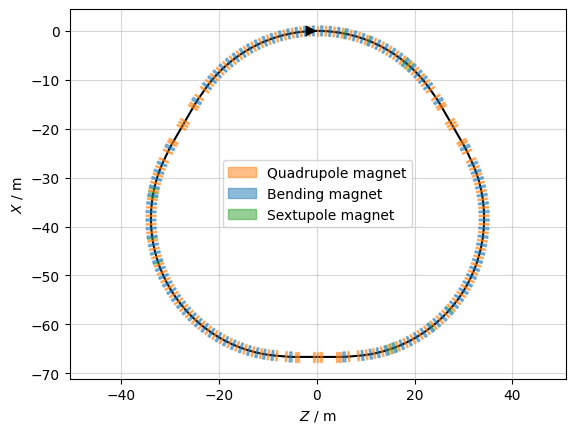

In [1015]:
ring=S1+S2+S3+S4+S5+S6
ring.survey().plot()

In [ ]:
tw1 = ring.twiss(
                betx=0.15, bety=0.15, py=1e-6)
tw1.plot()

In [ ]:
# Create a tiny line of just one arc cell
# Assuming your cell structure is: Drarc, Bend, Drarc, QDA, Drarc, Bend, Drarc, QFA
fodo_cell = xt.Line(elements=[
    pdr.elements['Drarc1_1R1'], pdr.elements['Bend1_1R1'],
    pdr.elements['Drarc2_1R1'], pdr.elements['QDA_1R1'],
    pdr.elements['Drarc3_1R1'], pdr.elements['Bend2_1R1'],
    pdr.elements['QFA_1R1']
], element_names=['d1', 'b1', 'd2', 'qda', 'd3', 'b2', 'qfa'])

fodo_cell.particle_ref = ring.particle_ref

try:
    tw_cell = fodo_cell.twiss(method='4d')
    print(f"Cell Stable! Max Betx: {max(tw_cell.betx):.2f}m, Max Bety: {max(tw_cell.bety):.2f}m")
    # Save this as the starting point for the DS check
    tw_init_arc = tw_cell.get_twiss_init('qfa')
except Exception as e:
    print(f"Arc Cell is unstable: {e}")

In [ ]:
# Define the range for the DS in your S1 line
# Look for the element where the DS starts and ends
tw_ds = S1.twiss(
    start=f'Drarc1_1R1', 
    end=f'QDTrip_1R1', 
    init=tw_init_arc
)

import matplotlib.pyplot as plt
plt.plot(tw_ds.s, tw_ds.dx)
plt.title("Dispersion through Suppressor")
plt.ylabel("Dx [m]")
plt.axhline(0, color='red', linestyle='--')
plt.show()

if abs(tw_ds.dx[-1]) > 0.01:
    print(f"DS Failure: Dispersion is {tw_ds.dx[-1]:.4f}m at exit (target is 0)")